<h2 style="color: purple">Imports</h2>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error

#### Garantir que os gráficos apareçam no notebook, carregar o csv e ver as primeiras 5 linhas

In [3]:
%matplotlib inline

df = pd.read_csv("NFLX.csv")

display(df.head())

print("\nDimensões do dataset:", df.shape)
print("\nTipos de dados:")
print(df.dtypes)

,Date,Open,High,Low,Close,Adj Close,Volume
0,2023-02-01,353.859985,365.390015,349.910004,361.989990,361.989990,8005200
1,2023-02-02,365.160004,368.320007,358.429993,366.890015,366.890015,7857000
2,2023-02-03,359.079987,379.429993,359.000000,365.899994,365.899994,9402000
3,2023-02-06,363.640015,368.450012,360.679993,361.480011,361.480011,4994900
4,2023-02-07,358.510010,364.179993,354.179993,362.950012,362.950012,6289400



Dimensões do dataset: (251, 7)

Tipos de dados:
Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object


#### Converter a coluna Date para date time, ordenar por data e confirmar o intervalo temporal

In [4]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

print("Primeira data:", df["Date"].min())
print("Última data :", df["Date"].max())

Primeira data: 2023-02-01 00:00:00
Última data : 2024-01-31 00:00:00


<h2 style="color: green">Análise Exploratória</h2>

In [5]:
print("\nEstatísticas descritivas das variáveis numéricas:")
display(df.describe())


Estatísticas descritivas das variáveis numéricas:


,Date,Open,High,Low,Close,Adj Close,Volume
count,251,251.000000,251.000000,251.000000,251.000000,251.000000,2.510000e+02
mean,2023-08-01 05:44:13.386454272,404.181354,409.754742,398.958446,404.270478,404.270478,6.135308e+06
min,2023-02-01 00:00:00,287.339996,297.450012,285.329987,292.760010,292.760010,1.404700e+06
25%,2023-05-02 12:00:00,348.994995,356.860001,344.490005,348.119995,348.119995,3.966000e+06
50%,2023-08-02 00:00:00,412.000000,418.839996,407.399994,411.690002,411.690002,5.128900e+06
75%,2023-10-30 12:00:00,444.729996,448.574997,439.175003,444.944992,444.944992,6.880600e+06
max,2024-01-31 00:00:00,571.349976,579.640015,562.679993,575.789978,575.789978,2.807440e+07
std,NaN,60.849872,61.318707,60.722608,61.193722,61.193722,3.814621e+06


### Evolução do preço de fecho (Close) ao longo do tempo

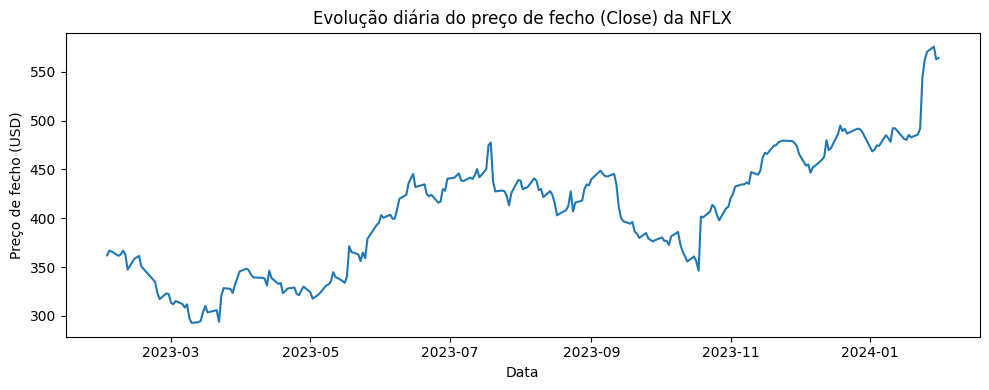

In [6]:
plt.figure(figsize=(10, 4))
plt.plot(df["Date"], df["Close"])
plt.title("Evolução diária do preço de fecho (Close) da NFLX")
plt.xlabel("Data")
plt.ylabel("Preço de fecho (USD)")
plt.tight_layout()
plt.show()

### Evolução do volume ao longo do tempo

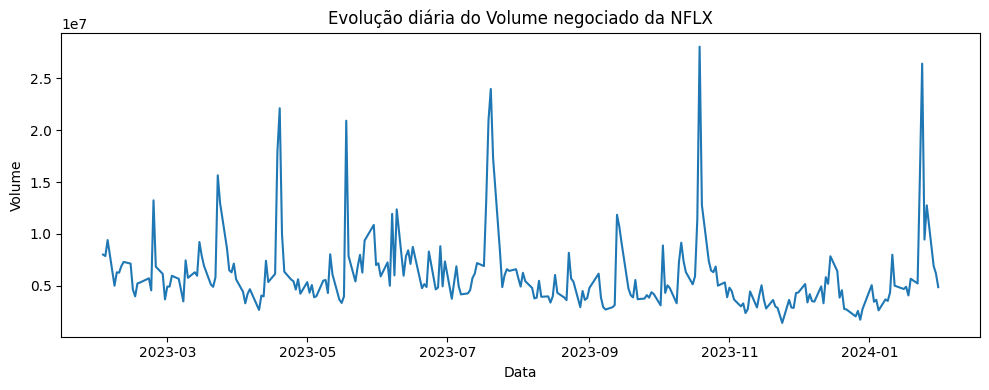

In [7]:
plt.figure(figsize=(10, 4))
plt.plot(df["Date"], df["Volume"])
plt.title("Evolução diária do Volume negociado da NFLX")
plt.xlabel("Data")
plt.ylabel("Volume")
plt.tight_layout()
plt.show()

### Matriz de correlação simples entre variáveis originais

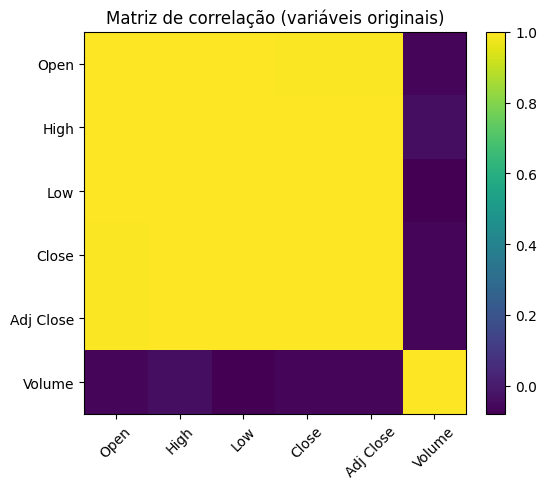

In [8]:
plt.figure(figsize=(6, 5))
corr = df[["Open", "High", "Low", "Close", "Adj Close", "Volume"]].corr()
im = plt.imshow(corr, cmap="viridis")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Matriz de correlação (variáveis originais)")
plt.tight_layout()
plt.show()

<h2 style="color: blue">Criação de features para o modelo (derivadas para +2 valures extra)</h2>

In [9]:
df_fe = df.copy()

### features base (relativas ao próprio dia)
### Open, High, Low, Volume já existem

In [10]:
df_fe["daily_range"] = df_fe["High"] - df_fe["Low"]  # amplitude diária

### features com informação de dias anteriores (sem usar dados futuros)

In [11]:
df_fe["close_prev_1"] = df_fe["Close"].shift(1)  # fecho do dia anterior

### diferença entre o preço de abertura e o fecho do dia anterior (gap)

In [12]:
df_fe["gap_open_prevclose"] = df_fe["Open"] - df_fe["close_prev_1"]

### médias móveis simples de Volume e da amplitude diária (usando apenas dias anteriores)

In [13]:
df_fe["vol_ma3"] = df_fe["Volume"].rolling(window=3).mean().shift(1)       # média de volume dos 3 dias anteriores
df_fe["range_ma3"] = df_fe["daily_range"].rolling(window=3).mean().shift(1)  # média de amplitude dos 3 dias anteriores

### informação de calendário

In [14]:
df_fe["day_of_week"] = df_fe["Date"].dt.dayofweek  # 0=segunda, ..., 4=sexta (NASDAQ)


### remover linhas com valores em falta (resultantes das operações de shift/rolling)

In [15]:
df_model = df_fe.dropna().reset_index(drop=True)

### Dimensões

In [16]:
print("Dimensões após criação de features e remoção de NaN:", df_model.shape)

Dimensões após criação de features e remoção de NaN: (248, 13)


### ver algumas linhas das novas features

In [17]:
display(df_model[[
    "Date", "Open", "High", "Low", "Close", "Volume",
    "daily_range", "close_prev_1", "gap_open_prevclose",
    "vol_ma3", "range_ma3", "day_of_week"
]].head())

,Date,Open,High,Low,Close,Volume,daily_range,close_prev_1,gap_open_prevclose,vol_ma3,range_ma3,day_of_week
0,2023-02-06,363.640015,368.450012,360.679993,361.480011,4994900,7.770019,365.899994,-2.259979,8.421400e+06,15.266673,0
1,2023-02-07,358.510010,364.179993,354.179993,362.950012,6289400,10.000000,361.480011,-2.970001,7.417967e+06,12.696675,1
2,2023-02-08,360.019989,368.190002,358.309998,366.829987,6253200,9.880004,362.950012,-2.930023,6.895433e+06,12.733337,2
3,2023-02-09,372.410004,373.829987,361.739990,362.500000,6901100,12.089997,366.829987,5.580017,5.845833e+06,9.216674,3
4,2023-02-10,359.160004,362.140015,347.140015,347.359985,7291100,15.000000,362.500000,-3.339996,6.481233e+06,10.656667,4


<h2 style="color: orange">Definição de X (variáveis preditoras) e y (alvo)</h2>

### variável alvo: preço de fecho do próprio dia

In [18]:
y = df_model["Close"]

### conjunto de variáveis preditoras (originais + derivadas)

In [19]:
feature_cols = [
    "Open",
    "High",
    "Low",
    "Volume",
    "daily_range",
    "close_prev_1",
    "gap_open_prevclose",
    "vol_ma3",
    "range_ma3",
    "day_of_week"
]

X = df_model[feature_cols].copy()

print("Número de exemplos disponíveis:", len(X))
print("Número de features:", len(feature_cols))
print("Features utilizadas:", feature_cols)

Número de exemplos disponíveis: 248
Número de features: 10
Features utilizadas: ['Open', 'High', 'Low', 'Volume', 'daily_range', 'close_prev_1', 'gap_open_prevclose', 'vol_ma3', 'range_ma3', 'day_of_week']


<h2 style="color: #9137bbff">Particionamento temporal: treino / validação / teste</h2>
<h3 style="color: #9137bbff">(SEM mistura de datas e SEM shuffle)</h3>

In [20]:
n_total = len(X)

# 70% treino, 10% validação, 20% teste
n_train = int(n_total * 0.7)
n_val   = int(n_total * 0.1)
n_test  = n_total - n_train - n_val  # o resto

print(f"Total de exemplos: {n_total}")
print(f"Treino: {n_train}, Validação: {n_val}, Teste: {n_test}")

# garantir que a soma coincide
assert n_train + n_val + n_test == n_total

# índices temporais (já estão ordenados por data)
X_train = X.iloc[:n_train]
y_train = y.iloc[:n_train]

X_val   = X.iloc[n_train:n_train + n_val]
y_val   = y.iloc[n_train:n_train + n_val]

X_test  = X.iloc[n_train + n_val:]
y_test  = y.iloc[n_train + n_val:]

print("\nIntervalo de datas em cada subconjunto:")
print("Treino   :", df_model.loc[X_train.index, "Date"].min(), "->", df_model.loc[X_train.index, "Date"].max())
print("Validação:", df_model.loc[X_val.index,   "Date"].min(), "->", df_model.loc[X_val.index,   "Date"].max())
print("Teste    :", df_model.loc[X_test.index,  "Date"].min(), "->", df_model.loc[X_test.index,  "Date"].max())

Total de exemplos: 248
Treino: 173, Validação: 24, Teste: 51

Intervalo de datas em cada subconjunto:
Treino   : 2023-02-06 00:00:00 -> 2023-10-12 00:00:00
Validação: 2023-10-13 00:00:00 -> 2023-11-15 00:00:00
Teste    : 2023-11-16 00:00:00 -> 2024-01-31 00:00:00


<h2 style="color: #5fce37ff">Modelo 1 – Regressão Linear Múltipla</h2>

In [21]:
# criar e treinar o modelo com dados de treino
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# avaliar no conjunto de validação
y_val_pred_lin = lin_reg.predict(X_val)

r2_val_lin = r2_score(y_val, y_val_pred_lin)
rmse_val_lin = mean_squared_error(y_val, y_val_pred_lin)

print("Desempenho da Regressão Linear na validação:")
print(f"  R^2  (val): {r2_val_lin:.4f}")
print(f"  RMSE (val): {rmse_val_lin:.4f}")

Desempenho da Regressão Linear na validação:
  R^2  (val): 0.9936
  RMSE (val): 6.0354


<h2 style="color: #10a591ff">KNN</h2>

In [22]:
# Preparação dos dados para o KNN (normalização simples)
# normalização min-max baseada APENAS nos dados de treino
X_train_min = X_train.min()
X_train_max = X_train.max()

# evitar divisão por zero (caso raro)
denom = (X_train_max - X_train_min)
denom[denom == 0] = 1.0

X_train_scaled = (X_train - X_train_min) / denom
X_val_scaled   = (X_val   - X_train_min) / denom
X_test_scaled  = (X_test  - X_train_min) / denom

print("Dimensões dos conjuntos escalados (treino, validação, teste):")
print(X_train_scaled.shape, X_val_scaled.shape, X_test_scaled.shape)

Dimensões dos conjuntos escalados (treino, validação, teste):
(173, 10) (24, 10) (51, 10)


<h2 style="color: #10a591ff">KNN Regressor (afinação do K usando validação)</h2>

In [23]:
melhor_k = None
melhor_r2_val = -np.inf
resultados_knn = []

# vamos testar alguns valores de K (ex.: de 2 a 20)
for k in range(2, 21):
    knn_reg = KNeighborsRegressor(n_neighbors=k)
    knn_reg.fit(X_train_scaled, y_train)
    
    y_val_pred_knn = knn_reg.predict(X_val_scaled)
    r2_val_knn = r2_score(y_val, y_val_pred_knn)
    rmse_val_knn = mean_squared_error(y_val, y_val_pred_knn)
    
    resultados_knn.append((k, r2_val_knn, rmse_val_knn))
    
    if r2_val_knn > melhor_r2_val:
        melhor_r2_val = r2_val_knn
        melhor_k = k

print("Resultados na validação para vários valores de K:")
for k, r2_k, rmse_k in resultados_knn:
    print(f"K={k:2d} -> R^2={r2_k:.4f}, RMSE={rmse_k:.4f}")

print("\nMelhor K encontrado (validação):", melhor_k)
print("Melhor R^2 na validação:", melhor_r2_val)

Resultados na validação para vários valores de K:
K= 2 -> R^2=0.8725, RMSE=120.9814
K= 3 -> R^2=0.8948, RMSE=99.8636
K= 4 -> R^2=0.9307, RMSE=65.7622
K= 5 -> R^2=0.9298, RMSE=66.5802
K= 6 -> R^2=0.9239, RMSE=72.2556
K= 7 -> R^2=0.9073, RMSE=87.9970
K= 8 -> R^2=0.9083, RMSE=87.0357
K= 9 -> R^2=0.9199, RMSE=76.0283
K=10 -> R^2=0.9098, RMSE=85.6321
K=11 -> R^2=0.9037, RMSE=91.3944
K=12 -> R^2=0.9019, RMSE=93.1176
K=13 -> R^2=0.8956, RMSE=99.0367
K=14 -> R^2=0.8897, RMSE=104.6443
K=15 -> R^2=0.8830, RMSE=111.0136
K=16 -> R^2=0.8866, RMSE=107.6593
K=17 -> R^2=0.8820, RMSE=112.0199
K=18 -> R^2=0.8870, RMSE=107.2442
K=19 -> R^2=0.8852, RMSE=108.9612
K=20 -> R^2=0.8729, RMSE=120.5932

Melhor K encontrado (validação): 4
Melhor R^2 na validação: 0.9307043910321671


### Re-treino dos modelos com treino + validação e avaliação dos testes finais

In [24]:
# regressão Linear com dados de treino+validação
X_train_val = pd.concat([X_train, X_val], axis=0)
y_train_val = pd.concat([y_train, y_val], axis=0)

lin_reg_final = LinearRegression()
lin_reg_final.fit(X_train_val, y_train_val)

y_test_pred_lin = lin_reg_final.predict(X_test)

r2_test_lin = r2_score(y_test, y_test_pred_lin)
rmse_test_lin = mean_squared_error(y_test, y_test_pred_lin)

print("Desempenho da Regressão Linear no conjunto de TESTE:")
print(f"  R^2  (test): {r2_test_lin:.4f}")
print(f"  RMSE (test): {rmse_test_lin:.4f}")

# KNN final, treinado com treino+validação
# recalcular normalização com Treino+Validação
X_train_val_min = X_train_val.min()
X_train_val_max = X_train_val.max()
denom_tv = (X_train_val_max - X_train_val_min)
denom_tv[denom_tv == 0] = 1.0

X_train_val_scaled = (X_train_val - X_train_val_min) / denom_tv
X_test_scaled_tv   = (X_test       - X_train_val_min) / denom_tv

knn_reg_final = KNeighborsRegressor(n_neighbors=melhor_k)
knn_reg_final.fit(X_train_val_scaled, y_train_val)

y_test_pred_knn = knn_reg_final.predict(X_test_scaled_tv)

r2_test_knn = r2_score(y_test, y_test_pred_knn)
rmse_test_knn = mean_squared_error(y_test, y_test_pred_knn)

print("\nDesempenho do KNN no conjunto de TESTE:")
print(f"  K   utilizado: {melhor_k}")
print(f"  R^2  (test): {r2_test_knn:.4f}")
print(f"  RMSE (test): {rmse_test_knn:.4f}")

Desempenho da Regressão Linear no conjunto de TESTE:
  R^2  (test): 0.9891
  RMSE (test): 10.0425

Desempenho do KNN no conjunto de TESTE:
  K   utilizado: 4
  R^2  (test): -1.6439
  RMSE (test): 2434.0634


### Comparação gráfica das previsões no TESTE

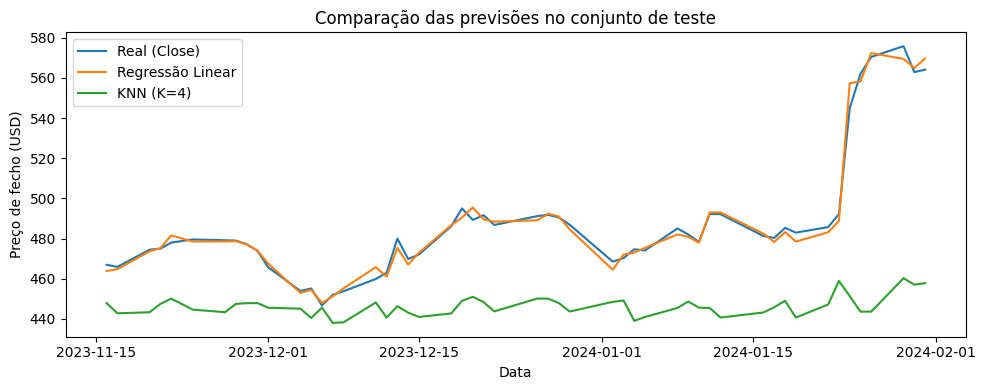

In [25]:
plt.figure(figsize=(10,4))
plt.plot(df_model.loc[X_test.index, "Date"], y_test.values, label="Real (Close)")
plt.plot(df_model.loc[X_test.index, "Date"], y_test_pred_lin, label="Regressão Linear")
plt.plot(df_model.loc[X_test.index, "Date"], y_test_pred_knn, label=f"KNN (K={melhor_k})")
plt.title("Comparação das previsões no conjunto de teste")
plt.xlabel("Data")
plt.ylabel("Preço de fecho (USD)")
plt.legend()
plt.tight_layout()
plt.show()

### Geração do ficheiro precos_estimados.csv (usando modelo final escolhido)

In [26]:
# aqui vamos assumir que o modelo FINAL escolhido para entrega é a Regressão Linear,
# dado o seu melhor desempenho em teste (poderá justificar isto no relatório).

precos_estimados = pd.DataFrame({
    "price": y_test_pred_lin  # previsões para o conjunto de teste, na ordem temporal correta
})

print("Dimensões de precos_estimados:", precos_estimados.shape)
display(precos_estimados.head())

# guardar em CSV (sem índice, apenas a coluna 'price')
precos_estimados.to_csv("precos_estimados.csv", index=False)
print("\nFicheiro 'precos_estimados.csv' gravado com sucesso.")

Dimensões de precos_estimados: (51, 1)


,price
0,463.863910
1,464.753873
2,473.695105
3,475.253364
4,481.596010



Ficheiro 'precos_estimados.csv' gravado com sucesso.


<h2 style="color: #12a510ff; text-decoration: underline">Resumo textual dos resultados</h2>

In [27]:
print("\n===============================================")
print("Modelo 1 – Regressão Linear Múltipla:")
print(f"  R^2  validação: {r2_val_lin:.4f}")
print(f"  R^2  teste     : {r2_test_lin:.4f}")
print(f"  RMSE teste     : {rmse_test_lin:.4f}")

print("\nModelo 2 – KNN Regressor:")
print(f"  Melhor K (validação): {melhor_k}")
print(f"  R^2  teste           : {r2_test_knn:.4f}")
print(f"  RMSE teste           : {rmse_test_knn:.4f}")

print("\nModelo escolhido para gerar 'precos_estimados.csv': Regressão Linear.")
print("===============================================")


Modelo 1 – Regressão Linear Múltipla:
  R^2  validação: 0.9936
  R^2  teste     : 0.9891
  RMSE teste     : 10.0425

Modelo 2 – KNN Regressor:
  Melhor K (validação): 4
  R^2  teste           : -1.6439
  RMSE teste           : 2434.0634

Modelo escolhido para gerar 'precos_estimados.csv': Regressão Linear.
